# Lesson 13 - Spatial graph neural networks on unstructured meshes (a learnt Poisson solver).


Questions this lesson answers
-----------------------------
* How do neural networks work on meshes that are not regular grids? (Graphs + message passing.)
* What is the difference between spectral (GCN) and spatial (message-passing) GNNs,
  and why do edge features (relative positions) matter for physics?
* Can a GNN trained on one family of meshes predict the FEM solution of -Laplace(u) = f
  on *new* meshes, including finer ones it never saw? Where does it break?

Data: P1 finite-element solutions (validated against a manufactured solution) on
jittered Delaunay meshes of the unit square, with random Gaussian-bump sources.

Script version:  python lessons/13_graph_nn_mesh/lesson.py

## Lesson 13 - Spatial graph neural networks on unstructured meshes

📄 [`lessons/13_graph_nn_mesh/lesson.py`](../lessons/13_graph_nn_mesh/lesson.py) · 📓 [`notebooks/13_graph_nn_mesh.ipynb`](13_graph_nn_mesh.ipynb) · code: [`nnaz/gnn.py`](../nnaz/gnn.py)

CFD and FEM meshes are not images, so CNNs do not apply directly. A mesh *is* a **graph**:
vertices carry node features (source term, coordinates, boundary flag), and mesh edges carry
edge features (the relative position $x_j-x_i$ and its length).

### The reference solver: P1 finite elements

We solve $-\Delta u=f$ on the unit square with $u=0$ on the boundary, on jittered Delaunay
meshes. On each triangle $T$ the hat functions have constant gradients $G$, the element
stiffness is $K_T=|T|\,GG^\top$, and the consistent mass matrix is
$M_T=\frac{|T|}{12}\begin{pmatrix}2&1&1\\1&2&1\\1&1&2\end{pmatrix}$. We assemble,
apply the Dirichlet condition, and solve the sparse system. The solver is **verified** with the
manufactured solution $u=\sin\pi x\sin\pi y$ (so $f=2\pi^2u$): the error drops by 4× per mesh
halving (second order).

### Two families of GNN layers

* **Spectral-derived: GCN** (Kipf and Welling, 2017). Filtering on the graph Laplacian reduces to
  $H'=\sigma(\tilde D^{-1/2}(A+I)\tilde D^{-1/2}HW)$. Each neighbour is averaged with a *fixed,
  isotropic* weight. The layer cannot tell a neighbour to the east from one to the west.
* **Spatial message passing: MPNN / MeshGraphNets** (Gilmer et al. 2017; Pfaff et al. 2021).
  $$ m_{ij}=\phi_e\big(h_i,h_j,e_{ij}\big),\qquad h_i\leftarrow h_i+\phi_v\Big(h_i,\sum_{j\in\mathcal N(i)}m_{ij}\Big) . $$
  The messages see the **edge geometry**, so the layer can build anisotropic, stencil-like
  operators: a learnt analogue of a finite-volume flux or a row of the FEM stiffness matrix.

Both use 12 layers, with the Dirichlet condition built into the output, so information travels
at most 12 edges. The Poisson problem is elliptic: every node influences every other node. On a
20×20 mesh 12 hops cover most of the domain; on a 30×30 mesh they do not. This is a real
limitation, and the finer-mesh test measures it.

<p align="center"><img src="../docs/lesson13/gnn_poisson.png" width="100%"><br><img src="../docs/lesson13/gnn_errors.png" width="55%"></p>

*(see the results table in the README)*

**Honest reading.**
* The spatial MPNN, which sees edge vectors, beats the isotropic GCN, and both beat the
  per-node MLP. Neighbour information and geometry matter.
* A median error of about 20 % is far from the FEM solver, which is cheap and exact up to
  $O(h^2)$ for this linear problem. A learnt Poisson solver is not a replacement for a
  sparse direct solve. The value of such models is for nonlinear, expensive physics
  (MeshGraphNets on fluids and cloth), where the same architecture applies.
* **Mesh-refinement failure.** On 30×30 meshes, finer than any seen in training, both GNNs
  degrade badly, even below the neighbour-blind MLP. Two reasons:
  1. 12 message-passing hops no longer span the domain;
  2. the edge vectors are shorter than anything in training. The discrete Laplacian scales like
     $1/h^2$, and the network has only learnt its behaviour at the training $h$.

  Remedies from the literature are multiscale / multigrid GNNs, features normalised by the local
  mesh size, or training on a range of resolutions. This is an important caveat for anyone
  hoping to "train coarse, deploy fine".



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
import time
from pathlib import Path
import numpy as np
import torch
from nnaz.common import banner, save_results, savefig, seed_everything, set_torch_threads, setup_matplotlib
from nnaz.gnn import GCN, MPNN, PointMLP, collate, fem_poisson, make_graph, rel_errors, square_mesh, train_gnn
LESSON = 13
plt = setup_matplotlib()

## 1. The reference solver: P1 finite elements, checked with a manufactured solution

In [2]:
def fem_part(rng):
    banner("1. The reference solver: P1 finite elements, checked with a manufactured solution")
    ns, errs = [9, 17, 33, 65], []
    for n in ns:
        P, tri, bnd = square_mesh(n, rng)
        ue = np.sin(np.pi * P[:, 0]) * np.sin(np.pi * P[:, 1])  # exact; -Laplace(ue) = 2 pi^2 ue
        u = fem_poisson(P, tri, bnd, 2 * np.pi ** 2 * ue)
        errs.append(float(np.linalg.norm(u - ue) / np.linalg.norm(ue)))
        print(f"  {n:3d} x {n:3d} nodes: rel. L2 nodal error {errs[-1]:.2e}")
    order = -np.polyfit(np.log(ns), np.log(errs), 1)[0]
    print(f"  observed order {order:.2f} (P1 FEM: 2)")
    return dict(fem_n=ns, fem_err=errs, fem_order=float(order))

## 2. Learning the solution operator f -> u on random meshes

In [3]:
def gnn_part(rng, quick):
    banner("2. Learning the solution operator f -> u on random meshes")
    n_train = 60 if quick else 400
    t0 = time.time()
    train = [make_graph(int(rng.integers(14, 21)), rng) for _ in range(n_train)]
    test = [make_graph(int(rng.integers(14, 21)), rng) for _ in range(50)]
    fine = [make_graph(30, rng) for _ in range(20)]          # finer than any training mesh
    print(f"  generated {n_train} training meshes (196-400 nodes) + test sets with FEM in {time.time() - t0:.0f}s")
    f_scale = np.std(np.concatenate([g["f"] for g in train]))
    u_scale = np.std(np.concatenate([g["u"] for g in train]))
    steps = 150 if quick else 2500
    models = {"MPNN (spatial, edge vectors), 12 layers": MPNN(K=12, h=32),
              "GCN (spectral-derived, isotropic), 12 layers": GCN(K=12, h=32),
              "per-node MLP (no neighbours)": PointMLP()}
    res = {}
    for name, m in models.items():
        torch.manual_seed(0)
        m.apply(lambda mod: mod.reset_parameters() if hasattr(mod, "reset_parameters") else None)
        n_par = sum(p.numel() for p in m.parameters())
        print(f"  training {name} ({n_par} params)")
        hist, t = train_gnn(m, train, f_scale, u_scale, steps=steps, B=4, lr=3e-3, log=500 if not quick else 0)
        e_test, e_fine = rel_errors(m, test, f_scale, u_scale), rel_errors(m, fine, f_scale, u_scale)
        res[name] = dict(params=n_par, train_s=t, test_median=float(np.median(e_test)),
                         test_p90=float(np.percentile(e_test, 90)), fine_median=float(np.median(e_fine)))
        print(f"    rel. L2 error: test meshes median {res[name]['test_median']:.3f} (90th pct"
              f" {res[name]['test_p90']:.3f}) | finer 30x30 meshes median {res[name]['fine_median']:.3f}")
    res["zero prediction"] = dict(test_median=1.0, fine_median=1.0)

    # figure: one test mesh
    g = test[3]
    m = models["MPNN (spatial, edge vectors), 12 layers"]
    with torch.no_grad():
        pred = m(collate([g], f_scale, u_scale)).numpy() * u_scale
    predg = models["GCN (spectral-derived, isotropic), 12 layers"]
    with torch.no_grad():
        pg = predg(collate([g], f_scale, u_scale)).numpy() * u_scale
    fig, axs = plt.subplots(1, 5, figsize=(18, 3.6))
    tri = g["tri"]
    axs[0].triplot(g["P"][:, 0], g["P"][:, 1], tri, lw=0.4, color="0.4"); axs[0].set_title(f"mesh ({len(g['P'])} nodes)")
    for a, v, ttl in [(axs[1], g["f"], "source f"), (axs[2], g["u"], "FEM solution u"),
                      (axs[3], pred, "MPNN prediction"), (axs[4], pg, "GCN prediction")]:
        vmax = np.abs(g["u"]).max() if a is not axs[1] else np.abs(v).max()
        tc = a.tripcolor(g["P"][:, 0], g["P"][:, 1], tri, v, shading="gouraud", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        a.set_title(ttl); fig.colorbar(tc, ax=a)
    for a in axs:
        a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
    savefig(fig, LESSON, "gnn_poisson.png")

    fig, ax = plt.subplots(figsize=(7, 3.4))
    names = [k for k in res if k != "zero prediction"]
    xx = np.arange(len(names))
    ax.bar(xx - 0.2, [res[k]["test_median"] for k in names], 0.4, label="test meshes (same size range)")
    ax.bar(xx + 0.2, [res[k]["fine_median"] for k in names], 0.4, label="finer 30x30 meshes")
    ax.axhline(1.0, color="k", ls=":", lw=0.8); ax.text(-0.4, 1.02, "zero prediction", fontsize=8)
    ax.set_xticks(xx, [k.split(",")[0].split(" (")[0] for k in names]); ax.set_ylabel("median rel. L2 error")
    ax.legend(fontsize=8); ax.set_title("learnt Poisson solvers on unseen meshes")
    savefig(fig, LESSON, "gnn_errors.png")
    return res

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [4]:
quick = False

In [5]:
rng = seed_everything(13)

In [6]:
set_torch_threads()

In [7]:
t0 = time.time()
res = fem_part(rng)
show_new_figures(t0, LESSON)


1. The reference solver: P1 finite elements, checked with a manufactured solution
    9 x   9 nodes: rel. L2 nodal error 3.95e-02
   17 x  17 nodes: rel. L2 nodal error 8.65e-03
   33 x  33 nodes: rel. L2 nodal error 2.22e-03


   65 x  65 nodes: rel. L2 nodal error 5.59e-04
  observed order 2.14 (P1 FEM: 2)



2. Learning the solution operator f -> u on random meshes


  generated 400 training meshes (196-400 nodes) + test sets with FEM in 11s
  training MPNN (spatial, edge vectors), 12 layers (119553 params)


    step   500  mse 2.88e-01  (42s)


    step  1000  mse 1.33e-01  (83s)


    step  1500  mse 7.64e-02  (123s)


...

    step  1000  mse 2.84e-01  (3s)


    step  1500  mse 2.76e-01  (5s)


    step  2000  mse 2.60e-01  (7s)


    step  2500  mse 2.60e-01  (9s)
    rel. L2 error: test meshes median 0.531 (90th pct 1.312) | finer 30x30 meshes median 0.667


  saved docs/lesson13/gnn_poisson.png
  saved docs/lesson13/gnn_errors.png


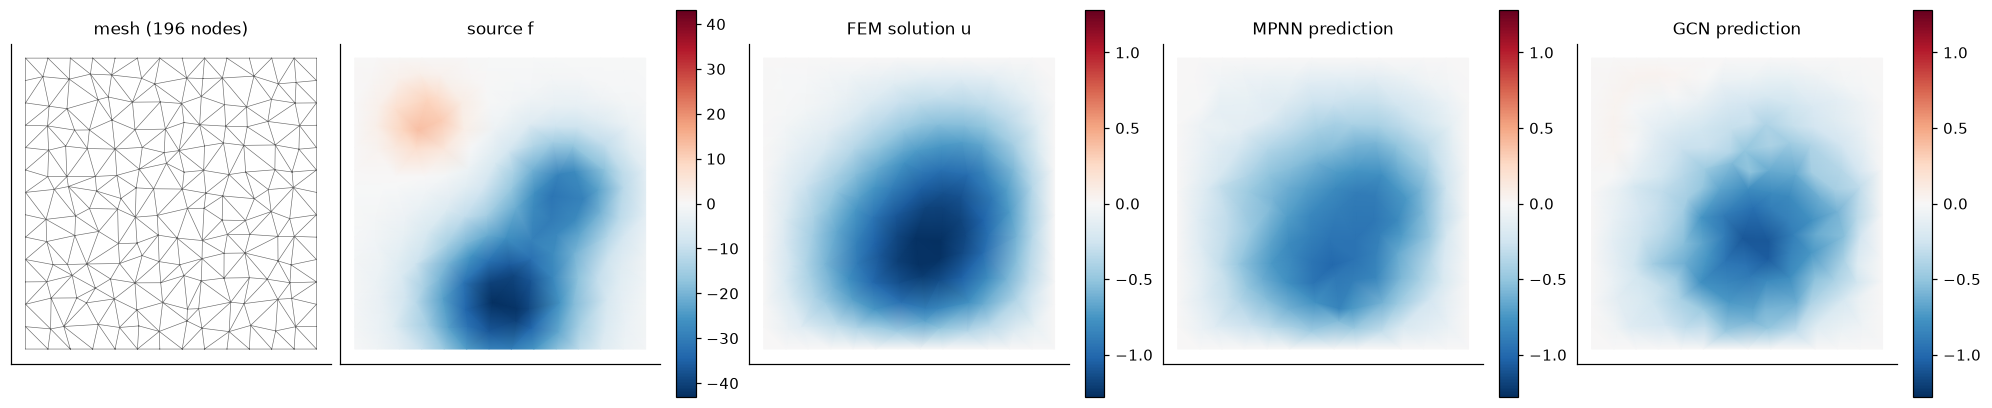

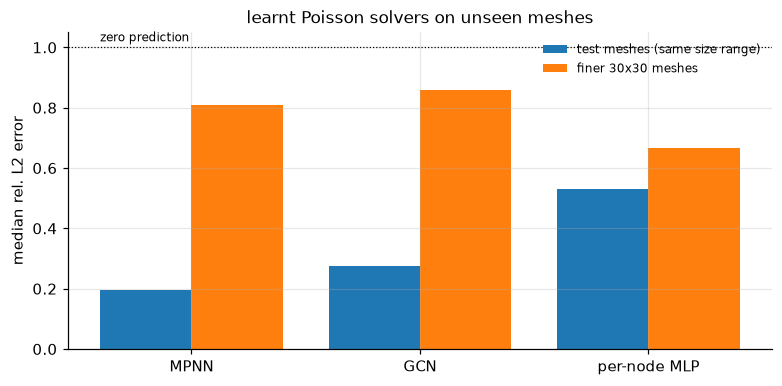

In [8]:
t0 = time.time()
res["gnn"] = gnn_part(rng, quick)
show_new_figures(t0, LESSON)

In [9]:
_ = save_results(LESSON, res)

In [10]:
res  # all numbers of this run

{'fem_n': [9, 17, 33, 65],
 'fem_err': [0.039522229592211196,
  0.008650100238853996,
  0.002215247894668716,
  0.0005594126748207951],
 'fem_order': 2.14224258577298,
 'gnn': {'MPNN (spatial, edge vectors), 12 layers': {'params': 119553,
   'train_s': 204.9207091331482,
   'test_median': 0.19681880837210058,
   'test_p90': 0.3453368444277419,
   'fine_median': 0.8090015548040481},
  'GCN (spectral-derived, isotropic), 12 layers': {'params': 14977,
   'train_s': 56.38205909729004,
   'test_median': 0.2759072574363851,
   'test_p90': 0.6617163279862436,
   'fine_median': 0.8587732594542132},
  'per-node MLP (no neighbours)': {'params': 17281,
   'train_s': 8.624542474746704,
   'test_median': 0.5312448839004409,
   'test_p90': 1.3115343477628603,
   'fine_median': 0.6670718181057287},
  'zero prediction': {'test_median': 1.0, 'fine_median': 1.0}}}